# Clickstream Analytics Pipeline 



In [1]:
#pip install pyspark delta-spark

In [2]:
import os
import pyspark
from pyspark.sql import SparkSession
import warnings
warnings.filterwarnings('ignore')

spark = SparkSession.builder \
    .appName("ClickstreamPipeline") \
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension") \
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog") \
    .config("spark.jars.packages", "io.delta:delta-spark_2.13:4.0.0") \
    .config("spark.sql.shuffle.partitions", "4") \
    .master("local[*]") \
    .getOrCreate()

print(f"PySpark version: {spark.version}")
print("Spark session ready with Delta Lake support")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/23 13:09:04 WARN Utils: Your hostname, Luizas-MacBook-Air-2.local, resolves to a loopback address: 127.0.0.1; using 172.20.10.2 instead (on interface en0)
26/05/23 13:09:04 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
:: loading settings :: url = jar:file:/opt/anaconda3/lib/python3.9/site-packages/pyspark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /Users/luiza/.ivy2.5.2/cache
The jars for the packages stored in: /Users/luiza/.ivy2.5.2/jars
io.delta#delta-spark_2.13 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-ffb17221-dfac-4cb1-9283-7e872d03e21c;1.0
	confs: [default]
	found io.delta#delta-spark_2.13;4.0.0 in central
	found io.delta#delta-storage;4.0.0 in central
	found org.antlr#antlr4-runtime;4.13.1 in central
:: resolution report :: resolve 264ms :: artifacts dl 12ms
	:: modules in us

PySpark version: 4.0.2
Spark session ready with Delta Lake support


In [3]:
# Creating directories for data and checkpoints
dirs = [
    'data/raw', 'data/bronze', 'data/silver', 'data/gold',
    'checkpoints/bronze', 'checkpoints/silver'
]
for d in dirs:
    os.makedirs(d, exist_ok=True)
print('Directories created')

Directories created


In [4]:
# Generating fake clickstream data (this simulates Kafka messages)
import json as json_mod
import uuid
import random
from datetime import datetime, timedelta

USERS = [f'user_{i:04d}' for i in range(1, 201)]
PAGES = [
    '/home', '/products', '/products/electronics',
    '/products/electronics/laptop-pro', '/cart', '/checkout',
    '/search', '/products/clothing', '/products/books'
]
EVENT_TYPES = ['page_view', 'add_to_cart', 'search', 'purchase', 'remove_from_cart']

PRODUCTS = {
    '/products/electronics/laptop-pro': {'id': 'prod_001', 'price': 1299.99, 'category': 'electronics'},
    '/products/clothing': {'id': 'prod_002', 'price': 89.99, 'category': 'clothing'},
    '/products/books': {'id': 'prod_003', 'price': 39.99, 'category': 'books'},
}

def generate_event(user_id, ts):
    page = random.choice(PAGES)
    etype = random.choice(EVENT_TYPES)
    product = PRODUCTS.get(page, {})
    
    event = {
        'event_id': str(uuid.uuid4()),
        'user_id': user_id,
        'session_id': None,
        'event_type': etype,
        'page_url': page,
        'referrer_url': random.choice(PAGES) if random.random() > 0.5 else None,
        'product_id': product.get('id'),
        'timestamp': ts.isoformat() + 'Z',
        'user_agent': random.choice([
            'Mozilla/5.0 Chrome/120.0',
            'Mozilla/5.0 Safari/605.1',
            'Mozilla/5.0 Mobile Safari/16.0'
        ]),
        'ip_address': f'10.{random.randint(0,255)}.{random.randint(0,255)}.{random.randint(1,254)}',
        'metadata': {
            'price': product.get('price'),
            'category': product.get('category'),
            'search_query': f'best {random.choice(["laptop","jacket","book"])}' if etype == 'search' else None
        }
    }
    return event

def generate_session(user_id, start_time):
    events = []
    current_ts = start_time
    num_events = random.randint(2, 10)
    for _ in range(num_events):
        events.append(generate_event(user_id, current_ts))
        current_ts += timedelta(seconds=random.randint(10, 300))
    return events

def write_batch(batch_id, start_time, num_sessions=20):
    all_events = []
    for _ in range(num_sessions):
        uid = random.choice(USERS)
        offset = timedelta(seconds=random.randint(0, 300))
        all_events.extend(generate_session(uid, start_time + offset))
    all_events.sort(key=lambda e: e['timestamp'])
    filepath = f'data/raw/batch_{batch_id:04d}.jsonl'
    with open(filepath, 'w') as f:
        for event in all_events:
            f.write(json_mod.dumps(event) + '\n')
    return len(all_events)

base_time = datetime(2024, 3, 15, 10, 0, 0)
total_events = 0
for i in range(1, 11):
    t = base_time + timedelta(minutes=i * 5)
    n = write_batch(i, t, num_sessions=15)
    total_events += n
    print(f'Batch {i:02d}: {n} events')
print(f'Total events generated: {total_events}')

Batch 01: 102 events
Batch 02: 82 events
Batch 03: 106 events
Batch 04: 101 events
Batch 05: 86 events
Batch 06: 98 events
Batch 07: 102 events
Batch 08: 96 events
Batch 09: 103 events
Batch 10: 86 events
Total events generated: 962


In [5]:
# Bronze Layer: Streaming JSON files into Delta table
from pyspark.sql.types import *
from pyspark.sql.functions import col, current_timestamp, to_timestamp, input_file_name, lit
import warnings
warnings.filterwarnings('ignore')

clickstream_schema = StructType([
    StructField('event_id', StringType(), False),
    StructField('user_id', StringType(), False),
    StructField('session_id', StringType(), True),
    StructField('event_type', StringType(), False),
    StructField('page_url', StringType(), True),
    StructField('referrer_url', StringType(), True),
    StructField('product_id', StringType(), True),
    StructField('timestamp', StringType(), False),
    StructField('user_agent', StringType(), True),
    StructField('ip_address', StringType(), True),
    StructField('metadata', StructType([
        StructField('price', DoubleType(), True),
        StructField('category', StringType(), True),
        StructField('search_query', StringType(), True)
    ]))
])

raw_stream = spark.readStream \
    .format('json') \
    .schema(clickstream_schema) \
    .option('maxFilesPerTrigger', 2) \
    .load('data/raw')

bronze_with_meta = raw_stream \
    .withColumn('event_timestamp', to_timestamp(col('timestamp'))) \
    .withColumn('ingestion_time', current_timestamp()) \
    .withColumn('source_file', input_file_name()) \
    .withColumn('pipeline_version', lit('v1.0'))

bronze_query = bronze_with_meta.writeStream \
    .format('delta') \
    .outputMode('append') \
    .option('checkpointLocation', 'checkpoints/bronze') \
    .trigger(processingTime='10 seconds') \
    .start('data/bronze')

print('Bronze streaming started...')
import time
time.sleep(30)
bronze_query.stop()
print(f'Bronze rows: {spark.read.format("delta").load("data/bronze").count()}')

26/05/23 13:09:11 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.


Bronze streaming started...


26/05/23 13:09:41 WARN DAGScheduler: Failed to cancel job group 5860a27d-4d7b-4082-be09-fa6269813a93. Cannot find active jobs for it.
26/05/23 13:09:41 WARN DAGScheduler: Failed to cancel job group 5860a27d-4d7b-4082-be09-fa6269813a93. Cannot find active jobs for it.
26/05/23 13:09:44 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Bronze rows: 923


In [6]:
# Silver Layer: Sessionizationing using window functions
from pyspark.sql.functions import lag, unix_timestamp, sum as spark_sum, when, concat, lit, trim, lower, col
from pyspark.sql.window import Window

bronze_df = spark.read.format('delta').load('data/bronze')

# Cleaning and deduplicating
cleaned_df = bronze_df \
    .withColumn('event_type', lower(trim(col('event_type')))) \
    .filter(col('user_id').isNotNull() & col('event_timestamp').isNotNull()) \
    .dropDuplicates(['event_id'])

# Sessionization algorithm
SESSION_GAP_SECONDS = 30 * 60
user_window = Window.partitionBy('user_id').orderBy('event_timestamp')

sessionized = cleaned_df \
    .withColumn('prev_timestamp', lag('event_timestamp', 1).over(user_window)) \
    .withColumn('gap_seconds',
        when(col('prev_timestamp').isNull(), 0)
        .otherwise(unix_timestamp('event_timestamp') - unix_timestamp('prev_timestamp'))
    ) \
    .withColumn('is_new_session', when(col('gap_seconds') > SESSION_GAP_SECONDS, 1).otherwise(0)) \
    .withColumn('session_number', spark_sum('is_new_session').over(user_window)) \
    .withColumn('session_id_derived',
        concat(col('user_id'), lit('_session_'), col('session_number').cast('string'))
    ) \
    .drop('prev_timestamp', 'gap_seconds', 'is_new_session', 'session_number')

# Writing to Silver Delta table
sessionized.write.format('delta').mode('overwrite') \
    .save('data/silver')

print(f'Silver rows: {spark.read.format("delta").load("data/silver").count()}')
print(f'Sessions created: {sessionized.select("session_id_derived").distinct().count()}')

Silver rows: 923


Sessions created: 105


In [7]:
import warnings
warnings.filterwarnings('ignore')
# Gold Layer: Star schema with session facts and user dimensions
silver_df = spark.read.format('delta').load('data/silver')
silver_df.createOrReplaceTempView('silver')

# Session facts table
session_facts = spark.sql('''
    SELECT
        session_id_derived AS session_id,
        user_id,
        MIN(event_timestamp) AS session_start,
        MAX(event_timestamp) AS session_end,
        COUNT(*) AS total_events,
        COUNT(DISTINCT page_url) AS unique_pages_visited,
        SUM(CASE WHEN event_type = 'add_to_cart' THEN 1 ELSE 0 END) AS cart_additions,
        SUM(CASE WHEN event_type = 'purchase' THEN 1 ELSE 0 END) AS purchases,
        SUM(CASE WHEN event_type = 'search' THEN 1 ELSE 0 END) AS searches,
        SUM(CASE WHEN event_type = 'purchase' AND metadata.price IS NOT NULL
                 THEN metadata.price ELSE 0 END) AS total_revenue,
        MAX(CASE WHEN event_type = 'purchase' THEN 1 ELSE 0 END) AS converted,
        CAST((unix_timestamp(MAX(event_timestamp)) - unix_timestamp(MIN(event_timestamp))) / 60.0
             AS DOUBLE) AS session_duration_minutes
    FROM silver
    GROUP BY session_id_derived, user_id
''')

session_facts.write.format('delta').mode('overwrite').save('data/gold/session_facts')

# Registering as temp view so the user_dim SQL below can reference it
session_facts.createOrReplaceTempView('session_facts')

# User dimension table
user_dim = spark.sql('''
    SELECT
        user_id,
        MIN(session_start) AS first_seen,
        MAX(session_start) AS last_seen,
        COUNT(*) AS lifetime_sessions,
        SUM(total_revenue) AS lifetime_revenue,
        SUM(purchases) AS lifetime_purchases,
        CASE
            WHEN SUM(total_revenue) > 1000 THEN 'high_value'
            WHEN SUM(total_revenue) > 200  THEN 'medium_value'
            WHEN SUM(purchases) > 0        THEN 'purchaser'
            ELSE 'browser'
        END AS user_segment
    FROM (SELECT user_id, session_start, total_revenue, purchases FROM session_facts)
    GROUP BY user_id
''')

user_dim.write.format('delta').mode('overwrite').save('data/gold/dim_users')

print(f'Gold session facts: {spark.read.format("delta").load("data/gold/session_facts").count()} rows')
print(f'Gold user dimensions: {spark.read.format("delta").load("data/gold/dim_users").count()} rows')

Gold session facts: 105 rows


Gold user dimensions: 105 rows


In [8]:
# Analytical Queries
import warnings
warnings.filterwarnings('ignore')

# Registering Gold tables as temp views (required in Spark 4.x)
spark.read.format('delta').load('data/gold/session_facts').createOrReplaceTempView('session_facts')
spark.read.format('delta').load('data/gold/dim_users').createOrReplaceTempView('dim_users')

# Query 1: Conversion funnel
print('=' * 60)
print('QUERY 1: Conversion Funnel')
print('=' * 60)
spark.sql('''
    SELECT
        COUNT(DISTINCT session_id) AS total_sessions,
        COUNT(DISTINCT CASE WHEN cart_additions > 0 THEN session_id END) AS sessions_with_cart,
        COUNT(DISTINCT CASE WHEN purchases > 0 THEN session_id END) AS sessions_with_purchase,
        ROUND(COUNT(DISTINCT CASE WHEN purchases > 0 THEN session_id END) * 100.0 /
              COUNT(DISTINCT session_id), 1) AS conversion_rate_pct,
        ROUND(SUM(total_revenue), 2) AS total_revenue
    FROM session_facts
''').show()

# Query 2: User segments
print('=' * 60)
print('QUERY 2: User Segments')
print('=' * 60)
spark.sql('''
    SELECT user_segment, COUNT(*) AS users, ROUND(SUM(lifetime_revenue), 2) AS total_rev
    FROM dim_users
    GROUP BY user_segment
    ORDER BY total_rev DESC
''').show()

# Query 3: Session metrics
print('=' * 60)
print('QUERY 3: Session Metrics')
print('=' * 60)
spark.sql('''
    SELECT
        CASE
            WHEN session_duration_minutes < 1  THEN 'Under 1 min'
            WHEN session_duration_minutes < 5  THEN '1-5 min'
            WHEN session_duration_minutes < 15 THEN '5-15 min'
            ELSE 'Over 15 min'
        END AS duration_bucket,
        COUNT(*) AS sessions,
        ROUND(AVG(total_revenue), 2) AS avg_revenue
    FROM session_facts
    GROUP BY duration_bucket
    ORDER BY avg_revenue DESC
''').show()

QUERY 1: Conversion Funnel


+--------------+------------------+----------------------+-------------------+-------------+
|total_sessions|sessions_with_cart|sessions_with_purchase|conversion_rate_pct|total_revenue|
+--------------+------------------+----------------------+-------------------+-------------+
|           105|                84|                    76|               72.4|     32259.43|
+--------------+------------------+----------------------+-------------------+-------------+

QUERY 2: User Segments


+------------+-----+---------+
|user_segment|users|total_rev|
+------------+-----+---------+
|  high_value|   22| 30509.68|
|   purchaser|   54|  1749.75|
|     browser|   29|      0.0|
+------------+-----+---------+

QUERY 3: Session Metrics
+---------------+--------+-----------+
|duration_bucket|sessions|avg_revenue|
+---------------+--------+-----------+
|    Over 15 min|      66|     401.51|
|       5-15 min|      28|     156.42|
|        1-5 min|       9|     153.33|
|    Under 1 min|       2|        0.0|
+---------------+--------+-----------+



In [9]:
import os
from delta.tables import DeltaTable
import warnings
warnings.filterwarnings('ignore')

SESSION_FACTS_PATH = os.path.abspath('data/gold/session_facts')
print(f'Using absolute path: {SESSION_FACTS_PATH}')

# Registering with absolute path so catalog resolves it correctly
spark.sql('DROP TABLE IF EXISTS session_facts_catalog')
spark.sql(f"""
    CREATE TABLE IF NOT EXISTS session_facts_catalog
    USING DELTA
    LOCATION '{SESSION_FACTS_PATH}'
""")

# Time Travel
print('Time Travel: View table history')
print('=' * 60)
dt = DeltaTable.forPath(spark, SESSION_FACTS_PATH)
dt.history().select(
    'version', 'timestamp', 'operation', 'operationParameters'
).show(truncate=False)

# Schema Evolution: Adding test column (idempotent)
print('Schema Evolution: Add test column')
print('=' * 60)

existing_columns = spark.read.format('delta').load(SESSION_FACTS_PATH).columns

if 'test_feature' not in existing_columns:
    spark.sql('ALTER TABLE session_facts_catalog ADD COLUMN test_feature STRING')
    print('Column added successfully')
else:
    print('Column test_feature already exists — skipping (idempotent run)')

# Verifying
print('Current schema:')
spark.read.format('delta').load(SESSION_FACTS_PATH).printSchema()

# OPTIMIZE with ZORDER
print('OPTIMIZE with ZORDER')
print('=' * 60)
dt.optimize().executeZOrderBy('user_id')
print('Table optimized')

print('Latest history entry:')
dt.history(1).select('version', 'timestamp', 'operation').show(truncate=False)

Using absolute path: /Users/luiza/data/gold/session_facts
Time Travel: View table history


+-------+-----------------------+-----------+-----------------------------------------------------------------------------------------------+
|version|timestamp              |operation  |operationParameters                                                                            |
+-------+-----------------------+-----------+-----------------------------------------------------------------------------------------------+
|6      |2026-05-23 13:10:35.598|WRITE      |{mode -> Overwrite, partitionBy -> []}                                                         |
|5      |2026-05-23 12:37:47.177|OPTIMIZE   |{predicate -> [], zOrderBy -> ["user_id"], clusterBy -> [], auto -> false}                     |
|4      |2026-05-23 12:34:48.558|WRITE      |{mode -> Overwrite, partitionBy -> []}                                                         |
|3      |2026-05-23 12:23:30.262|OPTIMIZE   |{predicate -> [], zOrderBy -> ["user_id"], clusterBy -> [], auto -> false}                     |
|2    

Table optimized
Latest history entry:
+-------+-----------------------+---------+
|version|timestamp              |operation|
+-------+-----------------------+---------+
|7      |2026-05-23 13:11:07.089|OPTIMIZE |
+-------+-----------------------+---------+



In [10]:
import os
import warnings
warnings.filterwarnings('ignore')

# Data Quality Checks
print('Data Quality Checks')
print('=' * 60)

BRONZE_PATH = os.path.abspath('data/bronze')
SESSION_FACTS_PATH = os.path.abspath('data/gold/session_facts')

bronze_df = spark.read.format('delta').load(BRONZE_PATH)
session_facts_df = spark.read.format('delta').load(SESSION_FACTS_PATH)

bronze_df.createOrReplaceTempView('bronze_dq')
session_facts_df.createOrReplaceTempView('session_facts_dq')

checks = [
    ('No null event_ids',       'SELECT COUNT(*) as fails FROM bronze_dq WHERE event_id IS NULL'),
    ('No null user_ids',        'SELECT COUNT(*) as fails FROM bronze_dq WHERE user_id IS NULL'),
    ('Non-negative revenue',    'SELECT COUNT(*) as fails FROM session_facts_dq WHERE total_revenue < 0'),
    ('Valid session durations', 'SELECT COUNT(*) as fails FROM session_facts_dq WHERE session_duration_minutes < 0'),
]

for check_name, query in checks:
    result = spark.sql(query).collect()[0][0]
    status = 'PASSED' if result == 0 else f'FAILED ({result} rows)'
    print(f'  {status}: {check_name}')

Data Quality Checks


  PASSED: No null event_ids
  PASSED: No null user_ids


  PASSED: Non-negative revenue
  PASSED: Valid session durations


**Visualizations**

In [11]:
import warnings
warnings.filterwarnings('ignore')

import os
import logging
logging.getLogger('py4j').setLevel(logging.ERROR)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# Loading all layers
bronze_df        = spark.read.format('delta').load(os.path.abspath('data/bronze'))
silver_df        = spark.read.format('delta').load(os.path.abspath('data/silver'))
session_facts_df = spark.read.format('delta').load(os.path.abspath('data/gold/session_facts'))
dim_users_df     = spark.read.format('delta').load(os.path.abspath('data/gold/dim_users'))

# Converting to Pandas
bronze_pd = bronze_df.select('event_type', 'page_url', 'event_timestamp').toPandas()
sf_pd     = session_facts_df.select(
                'session_id', 'total_events', 'session_duration_minutes',
                'cart_additions', 'purchases', 'total_revenue', 'converted'
            ).toPandas()
users_pd  = dim_users_df.select(
                'user_id', 'user_segment', 'lifetime_revenue', 'lifetime_sessions'
            ).toPandas()

bronze_pd['event_timestamp'] = pd.to_datetime(bronze_pd['event_timestamp'])

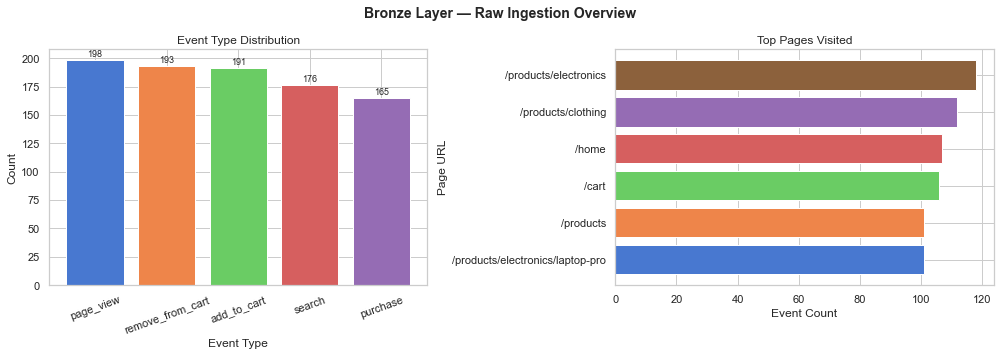

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Bronze Layer — Raw Ingestion Overview', fontsize=14, fontweight='bold')

# Event type distribution
event_counts = bronze_pd['event_type'].value_counts()
axes[0].bar(event_counts.index, event_counts.values,
            color=sns.color_palette('muted', len(event_counts)))
axes[0].set_title('Event Type Distribution')
axes[0].set_xlabel('Event Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(event_counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontsize=9)

# Top pages visited
page_counts = bronze_pd['page_url'].value_counts().head(6)
axes[1].barh(page_counts.index[::-1], page_counts.values[::-1],
             color=sns.color_palette('muted', len(page_counts)))
axes[1].set_title('Top Pages Visited')
axes[1].set_xlabel('Event Count')
axes[1].set_ylabel('Page URL')

plt.tight_layout()
plt.savefig('viz_bronze.png', bbox_inches='tight')
plt.show()

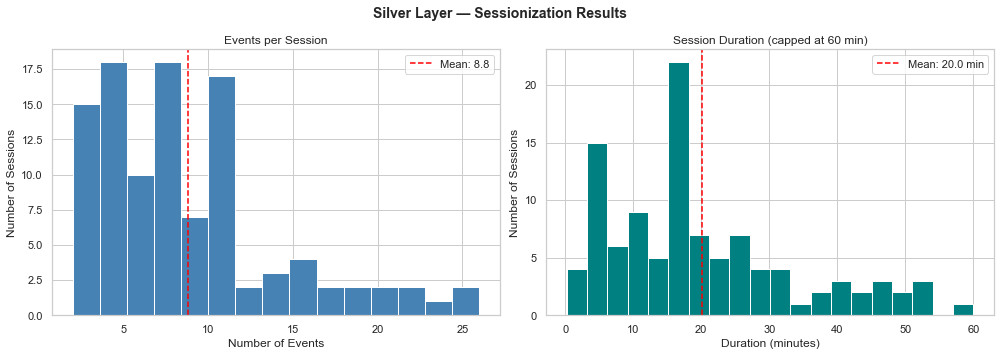

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Silver Layer — Sessionization Results', fontsize=14, fontweight='bold')

# Events per session
events_per_session = sf_pd['total_events']
axes[0].hist(events_per_session, bins=15, color='steelblue', edgecolor='white')
axes[0].set_title('Events per Session')
axes[0].set_xlabel('Number of Events')
axes[0].set_ylabel('Number of Sessions')
axes[0].axvline(events_per_session.mean(), color='red', linestyle='--',
                label=f'Mean: {events_per_session.mean():.1f}')
axes[0].legend()

# Session duration
dur = sf_pd['session_duration_minutes'].clip(upper=60)
axes[1].hist(dur, bins=20, color='teal', edgecolor='white')
axes[1].set_title('Session Duration (capped at 60 min)')
axes[1].set_xlabel('Duration (minutes)')
axes[1].set_ylabel('Number of Sessions')
axes[1].axvline(dur.mean(), color='red', linestyle='--',
                label=f'Mean: {dur.mean():.1f} min')
axes[1].legend()

plt.tight_layout()
plt.savefig('viz_silver.png', bbox_inches='tight')
plt.show()

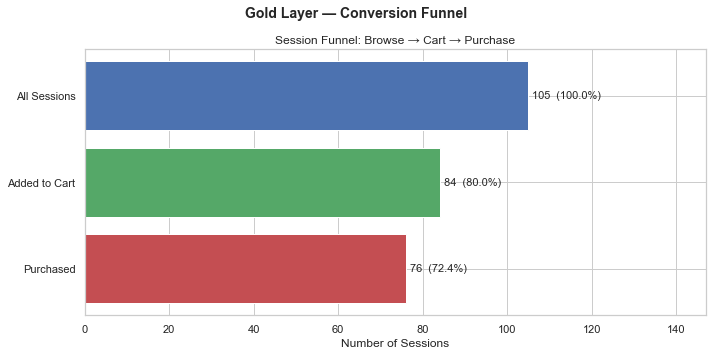

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Gold Layer — Conversion Funnel', fontsize=14, fontweight='bold')

total     = len(sf_pd)
with_cart = (sf_pd['cart_additions'] > 0).sum()
converted = (sf_pd['purchases'] > 0).sum()

stages = ['All Sessions', 'Added to Cart', 'Purchased']
counts = [total, with_cart, converted]
colors = ['#4C72B0', '#55A868', '#C44E52']

bars = ax.barh(stages[::-1], counts[::-1], color=colors[::-1])
ax.set_xlabel('Number of Sessions')
ax.set_title('Session Funnel: Browse → Cart → Purchase')

for bar, count in zip(bars, counts[::-1]):
    pct = count / total * 100
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f'{count:,}  ({pct:.1f}%)', va='center', fontsize=11)
ax.set_xlim(0, total * 1.4)

plt.tight_layout()
plt.savefig('viz_funnel.png', bbox_inches='tight')
plt.show()

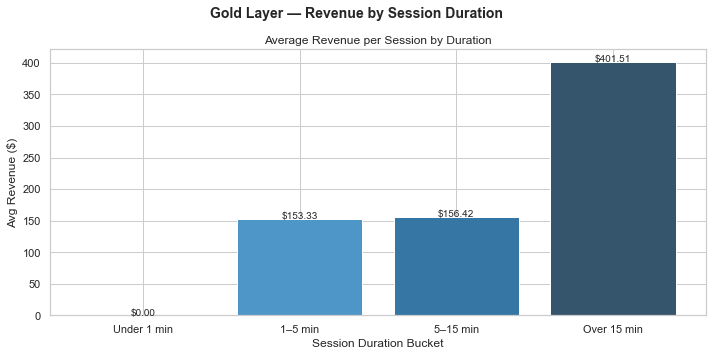

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Gold Layer — Revenue by Session Duration', fontsize=14, fontweight='bold')

def bucket(d):
    if d < 1:    return 'Under 1 min'
    elif d < 5:  return '1–5 min'
    elif d < 15: return '5–15 min'
    else:        return 'Over 15 min'

sf_pd['duration_bucket'] = sf_pd['session_duration_minutes'].apply(bucket)
order = ['Under 1 min', '1–5 min', '5–15 min', 'Over 15 min']
rev_by_bucket = sf_pd.groupby('duration_bucket')['total_revenue'].mean().reindex(order)

bars = ax.bar(rev_by_bucket.index, rev_by_bucket.values,
              color=sns.color_palette('Blues_d', len(order)))
ax.set_xlabel('Session Duration Bucket')
ax.set_ylabel('Avg Revenue ($)')
ax.set_title('Average Revenue per Session by Duration')
for i, v in enumerate(rev_by_bucket.values):
    ax.text(i, v + 0.3, f'${v:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('viz_revenue_duration.png', bbox_inches='tight')
plt.show()

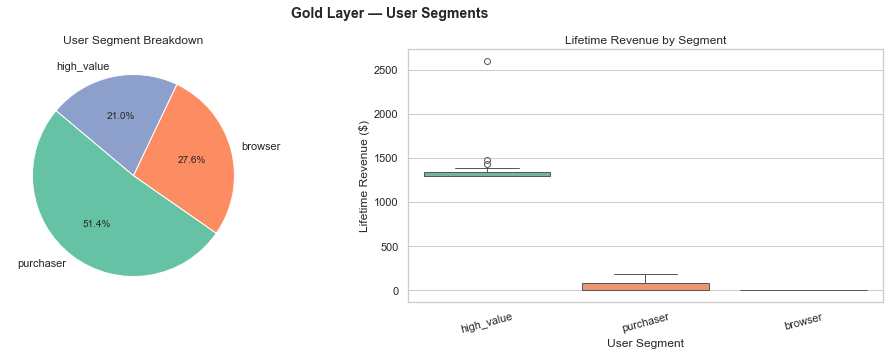

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Gold Layer — User Segments', fontsize=14, fontweight='bold')

# Pie chart
seg_counts = users_pd['user_segment'].value_counts()
axes[0].pie(seg_counts.values, labels=seg_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(seg_counts)), startangle=140)
axes[0].set_title('User Segment Breakdown')

# Box plot — lifetime revenue per segment
seg_order = [s for s in ['high_value', 'medium_value', 'purchaser', 'browser']
             if s in users_pd['user_segment'].unique()]
sns.boxplot(data=users_pd, x='user_segment', y='lifetime_revenue',
            order=seg_order, palette='Set2', ax=axes[1])
axes[1].set_title('Lifetime Revenue by Segment')
axes[1].set_xlabel('User Segment')
axes[1].set_ylabel('Lifetime Revenue ($)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('viz_segments.png', bbox_inches='tight')
plt.show()

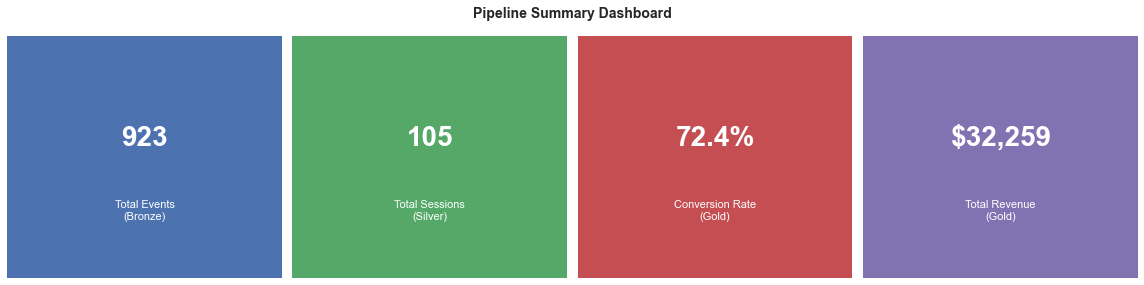

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Pipeline Summary Dashboard', fontsize=14, fontweight='bold')

def kpi_tile(ax, value, label, color):
    ax.set_facecolor(color)
    ax.text(0.5, 0.58, value, ha='center', va='center', fontsize=28,
            fontweight='bold', color='white', transform=ax.transAxes)
    ax.text(0.5, 0.28, label, ha='center', va='center', fontsize=11,
            color='white', transform=ax.transAxes, multialignment='center')
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

total_events    = len(bronze_pd)
total_sessions  = len(sf_pd)
conversion_rate = f"{(sf_pd['purchases'] > 0).mean() * 100:.1f}%"
total_revenue   = f"${sf_pd['total_revenue'].sum():,.0f}"

kpi_tile(axes[0], f'{total_events:,}',   'Total Events\n(Bronze)',    '#4C72B0')
kpi_tile(axes[1], f'{total_sessions:,}', 'Total Sessions\n(Silver)',  '#55A868')
kpi_tile(axes[2], conversion_rate,        'Conversion Rate\n(Gold)',   '#C44E52')
kpi_tile(axes[3], total_revenue,          'Total Revenue\n(Gold)',     '#8172B2')

plt.tight_layout()
plt.savefig('viz_dashboard.png', bbox_inches='tight')
plt.show()

